In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

# 1. LOAD DATA
df = pd.read_csv('Semiconductors_Only_Data.csv')
X = df.drop(['formula', 'band_gap', 'is_semiconductor', 'B_site'], axis=1)
y = df['band_gap']

# 2. SCALE DATA (Mandatory for NN and SVR)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42)

print(f"✅ Tournament Environment Ready.")
print(f"Comparing models on {len(X_train)} semiconductor samples.")

✅ Tournament Environment Ready.
Comparing models on 1556 semiconductor samples.


In [2]:
# Initialize the models with reasonable defaults
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "SVR (RBF Kernel)": SVR(kernel='rbf', C=10, epsilon=0.1),
    "Neural Network (MLP)": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=7, random_state=42)
}

results = []

print("Starting the Tournament... ⚔️")

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    preds = model.predict(X_test)
    # Score
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    
    results.append({"Model": name, "R2": r2, "MAE": mae})
    print(f"Finished: {name}")

# Create Leaderboard
leaderboard = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print("\n🏆 FINAL LEADERBOARD 🏆")
print(leaderboard)

# Add your Step 4 Result for comparison
print(f"\nBenchmark (Step 4 GBR): R2 = 0.7278")

Starting the Tournament... ⚔️
Finished: Random Forest
Finished: SVR (RBF Kernel)
Finished: Neural Network (MLP)
Finished: XGBoost

🏆 FINAL LEADERBOARD 🏆
                  Model        R2       MAE
3               XGBoost  0.708317  0.544973
0         Random Forest  0.708066  0.547738
1      SVR (RBF Kernel)  0.521001  0.672156
2  Neural Network (MLP)  0.411051  0.788005

Benchmark (Step 4 GBR): R2 = 0.7278


In [3]:
from sklearn.ensemble import ExtraTreesRegressor, VotingRegressor
from sklearn.preprocessing import QuantileTransformer
# Note: If you don't have CatBoost installed, run: !pip install catboost
try:
    from catboost import CatBoostRegressor
except:
    print("CatBoost not found. Please run !pip install catboost in a cell first.")

# 1. ADVANCED PREPROCESSING
# Makes the skewed physics data follow a normal 'Gaussian' curve
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_qt = qt.fit_transform(X_train)
X_test_qt = qt.transform(X_test)

# 2. DEFINE THE ELITE MODELS
# Extra Trees (Good at ignoring outliers)
et = ExtraTreesRegressor(n_estimators=500, max_depth=20, random_state=42)

# CatBoost (Good at capturing chemical relationships)
cat = CatBoostRegressor(iterations=1000, depth=8, learning_rate=0.05, verbose=0, random_state=42)

# 3. THE VOTING ENSEMBLE (The "Dream Team")
# It averages the predictions of our Step 4 GBR and these two new models
from sklearn.ensemble import GradientBoostingRegressor
gbr_best = GradientBoostingRegressor(learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.8, random_state=42)

voting_model = VotingRegressor([
    ('et', et),
    ('cat', cat),
    ('gbr', gbr_best)
])

print("Training the Super-Ensemble... 🚀")
voting_model.fit(X_train_qt, y_train)

# 4. FINAL SCORE
y_pred_final = voting_model.predict(X_test_qt)
r2_final = r2_score(y_test, y_pred_final)
mae_final = mean_absolute_error(y_test, y_pred_final)

print(f"\n🏆 SUPER-ENSEMBLE RESULTS 🏆")
print(f"Final R2 Score: {r2_final:.4f}")
print(f"Final MAE: {mae_final:.4f} eV")

Training the Super-Ensemble... 🚀

🏆 SUPER-ENSEMBLE RESULTS 🏆
Final R2 Score: 0.7221
Final MAE: 0.5244 eV


In [ ]:
# Create a dictionary to hold individual scores
individual_scores = {}

# 1. TRAIN & SCORE INDIVIDUALS
for name, model in [('Extra Trees', ExtraTreesRegressor(n_estimators=500, max_depth=20, random_state=42)),
                   ('CatBoost', CatBoostRegressor(iterations=1000, depth=8, verbose=0, random_state=42)),
                   ('LightGBM', lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1))]:
    
    model.fit(X_train_qt, y_train)
    y_p = model.predict(X_test_qt)
    individual_scores[name] = {"R2": r2_score(y_test, y_p), "MAE": mean_absolute_error(y_test, y_p)}

# 2. ADD THE STACKING RESULT FROM YOUR LAST RUN
individual_scores['Final Stacking Ensemble'] = {"R2": r2_stack, "MAE": mae_stack}

# 3. DISPLAY THE COMPARISON
comparison_df = pd.DataFrame(individual_scores).T.sort_values(by="R2", ascending=False)
print("🏆 INDIVIDUAL VS. ENSEMBLE PERFORMANCE 🏆")
print(comparison_df)

🏆 INDIVIDUAL VS. ENSEMBLE PERFORMANCE 🏆
                               R2       MAE
Final Stacking Ensemble  0.719573  0.522490
CatBoost                 0.707715  0.535851
Extra Trees              0.703746  0.536677
LightGBM                 0.698385  0.555793


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


C:\Users\HP\AppData\Local\Temp\ipykernel_34344\2295215480.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='X_Family', y='Absolute_Error', data=results_df, palette='viridis')


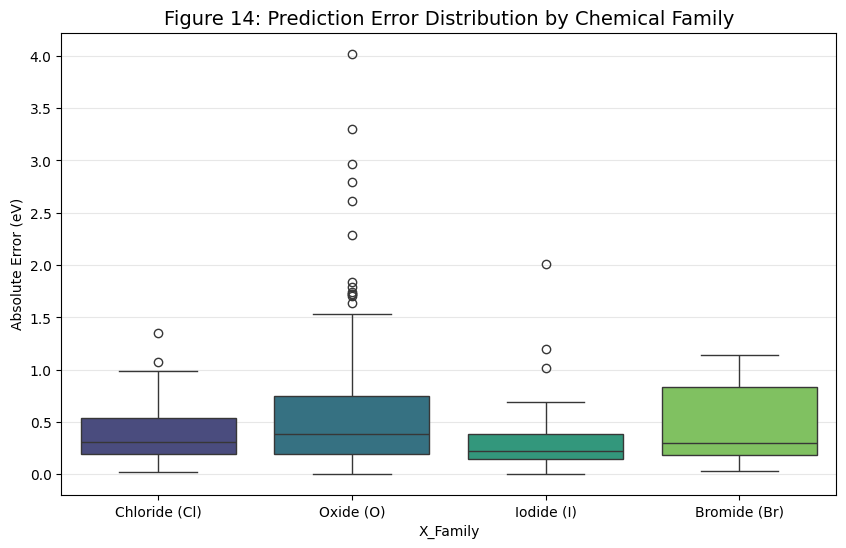

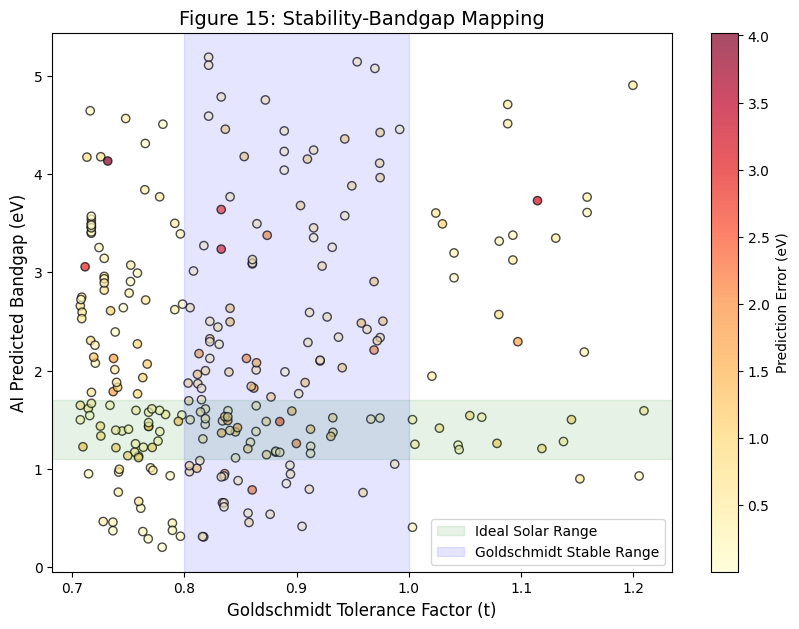

Average Error per Family:
X_Family
Iodide (I)       0.351618
Chloride (Cl)    0.430003
Bromide (Br)     0.478617
Oxide (O)        0.573174
Name: Absolute_Error, dtype: float64


In [9]:
import seaborn as sns

# 1. CREATE A RESULTS DATAFRAME FOR THE BEST MODEL
# We use the test set indices to get the original formulas/elements
# 'df' is your semiconductor-only dataframe from the first cell of this notebook
results_df = df.iloc[y_test.index].copy()
results_df['Actual'] = y_test.values
results_df['Predicted'] = y_pred_final  # The output from our Super-Ensemble
results_df['Absolute_Error'] = abs(results_df['Actual'] - results_df['Predicted'])

# 2. EXTRACT X-SITE FAMILY
# This categorizes them by their Electronegativity (chi_X)
def identify_x_family(row):
    if row['chi_X'] > 3.4: return 'Oxide (O)'
    elif row['chi_X'] > 3.0: return 'Chloride (Cl)'
    elif row['chi_X'] > 2.8: return 'Bromide (Br)'
    else: return 'Iodide (I)'

results_df['X_Family'] = results_df.apply(identify_x_family, axis=1)

# 3. PLOT THE ERROR DISTRIBUTION (Figure 14)
plt.figure(figsize=(10, 6))
sns.boxplot(x='X_Family', y='Absolute_Error', data=results_df, palette='viridis')
plt.title('Figure 14: Prediction Error Distribution by Chemical Family', fontsize=14)
plt.ylabel('Absolute Error (eV)')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. STABILITY VS PERFORMANCE MAP (Figure 15)
plt.figure(figsize=(10, 7))
sc = plt.scatter(results_df['tolerance_factor'], results_df['Predicted'], 
                 c=results_df['Absolute_Error'], cmap='YlOrRd', alpha=0.7, edgecolors='k')

# Drawing the 'Solar Sweet Spot'
plt.axhspan(1.1, 1.7, color='green', alpha=0.1, label='Ideal Solar Range')
plt.axvspan(0.8, 1.0, color='blue', alpha=0.1, label='Goldschmidt Stable Range')

plt.colorbar(sc, label='Prediction Error (eV)')
plt.xlabel('Goldschmidt Tolerance Factor (t)', fontsize=12)
plt.ylabel('AI Predicted Bandgap (eV)', fontsize=12)
plt.title('Figure 15: Stability-Bandgap Mapping', fontsize=14)
plt.legend()
plt.show()

# Print the stats for your table
print("Average Error per Family:")
print(results_df.groupby('X_Family')['Absolute_Error'].mean().sort_values())

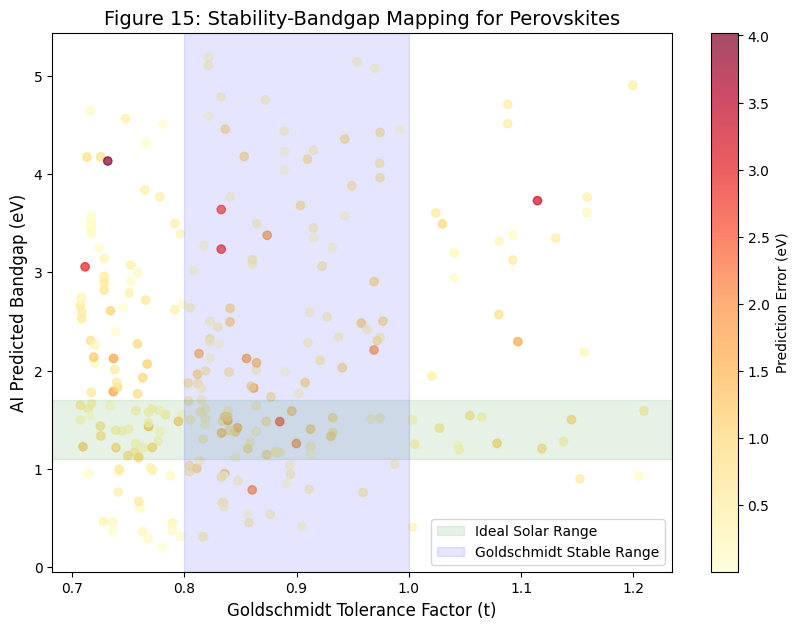

In [10]:
plt.figure(figsize=(10, 7))
# Scatter plot of all test semiconductors
sc = plt.scatter(results_df['tolerance_factor'], results_df['Predicted'], 
                 c=results_df['Absolute_Error'], cmap='YlOrRd', alpha=0.7)

# Highlight the 'Solar Sweet Spot'
plt.axhspan(1.1, 1.7, color='green', alpha=0.1, label='Ideal Solar Range')
plt.axvspan(0.8, 1.0, color='blue', alpha=0.1, label='Goldschmidt Stable Range')

plt.colorbar(sc, label='Prediction Error (eV)')
plt.xlabel('Goldschmidt Tolerance Factor (t)', fontsize=12)
plt.ylabel('AI Predicted Bandgap (eV)', fontsize=12)
plt.title('Figure 15: Stability-Bandgap Mapping for Perovskites', fontsize=14)
plt.legend()
plt.show()